# Void aspect ratio `r` — live cut-pattern toy

Move `r` (per cut, or all at once) and watch the flat cut pattern change.

**What `r` actually is.** Each cut node `C_ij` owns *two* vertices `x_ij` and `x'_ij`, both lying
on the straight cut through its neighbours:

```
x_ij  = r * a  +  (1-r) * b
x'_ij = (1-r) * a  +  r * b
```

so `r` slides the pair along that line, **symmetrically about the midpoint**. Their separation is
`|x - x'| = |1 - 2r| * |a - b|`: zero at `r = 0.5`, growing as `r` moves either way.

Those two vertices are the two hinge points the node contributes. So `r` sets **how far apart the
two hinges of a node sit** — which is exactly the aspect ratio of the void that opens there on
deployment. At `r = 0.5` the four panels around the node meet at a *single point* (the classic
rotating-squares hinge, symmetric void); away from `0.5` the pair separates and the void elongates.

**The cut topology never changes.** Verified below: 9 panels and 12 point-hinges, identical face
pairs and vertex ids, for every `r` in `(0,1)`. `r` moves geometry, not connectivity.

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import PolyCollection, LineCollection
from IPython.display import HTML, display

from nff.topology.closed_builder_jax import (
    build_deploy_structure, build_boundary_edges,
    boundary_flat_from_logits, solve_cut_vertices_jax)

%matplotlib inline
plt.rcParams["figure.dpi"] = 90

_CACHE = {}

def sheet(M=3, N=3, spacing=1.0):
    """Cached structure + jitted solve. 0.15 ms per evaluation, so sliders stay live."""
    key = (M, N, spacing)
    if key not in _CACHE:
        struct = build_deploy_structure(M, N)
        sliders = build_boundary_edges(struct, spacing=spacing, spacing_y=spacing)
        solve = jax.jit(lambda r, lg: solve_cut_vertices_jax(
            struct, boundary_flat_from_logits(sliders, lg), r))
        _CACHE[key] = (struct, sliders, solve)
    return _CACHE[key]


def geometry(r, M=3, N=3, logits=None, spacing=1.0):
    struct, sliders, solve = sheet(M, N, spacing)
    lg = jnp.zeros(sliders['n_logits']) if logits is None else jnp.asarray(logits, dtype=float)
    r_arr = jnp.broadcast_to(jnp.asarray(r, dtype=float), (struct['rows'], struct['cols']))
    coords = np.asarray(solve(r_arr, lg))
    return struct, coords, coords[np.asarray(struct['corner_pid'])]


EXPLODE = 0.05          # shrink panels toward their centroid so the cuts are visible

def panel_polys(panels, explode=EXPLODE):
    c = panels.mean(axis=1, keepdims=True)
    return c + (panels - c) * (1 - explode)


def pair_segments(coords):
    """The (x, x') pair of every node — the segment whose length is the void's long axis."""
    return np.stack([coords[0::2], coords[1::2]], axis=1)


def min_panel_area(panels):
    x, y = panels[..., 0], panels[..., 1]
    return np.abs(0.5 * np.sum(x * np.roll(y, -1, -1) - np.roll(x, -1, -1) * y, -1)).min()

print("ready")

ready


## The topology is constant — only geometry moves

Before the pictures, the claim above, checked against the actual `Tessellation` (not inferred from
coordinates).

In [2]:
from nff.topology.closed_builder import build_closed_tessellation

def topo_key(t):
    return sorted((tuple(sorted((h.face1, h.face2))), h.vertex1, h.vertex2) for h in t.hinges)

base = build_closed_tessellation(3, 3, r=np.full((4, 4), 0.25), spacing=1.0)
print(f"{'r':>6}  {'faces':>5} {'hinges':>6}   topology identical to r=0.25")
for r in (0.05, 0.25, 0.45, 0.50, 0.55, 0.75, 0.95):
    t = build_closed_tessellation(3, 3, r=np.full((4, 4), r), spacing=1.0)
    print(f"{r:>6}  {len(t.faces):>5} {len(t.hinges):>6}   {topo_key(t) == topo_key(base)}")

     r  faces hinges   topology identical to r=0.25
  0.05      9     12   True
  0.25      9     12   True
  0.45      9     12   True
   0.5      9     12   True
  0.55      9     12   True
  0.75      9     12   True
  0.95      9     12   True


## 1. The animation

`r` sweeping `0.03 -> 0.97`. Press play, or drag the scrubber. Orange = panels (drawn slightly
shrunk so the cuts read as white); blue dots = hinge points; red = each node's `(x, x')` pair,
the segment that becomes the void's long axis.

In [3]:
def make_animation(M=3, N=3, n_frames=61, lo=0.03, hi=0.97, figsize=(4.6, 4.9)):
    rs = np.linspace(lo, hi, n_frames)
    frames = [geometry(r, M, N) for r in rs]
    allc = np.concatenate([f[1] for f in frames])
    pad = 0.06 * (allc.max() - allc.min())

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(allc[:, 0].min() - pad, allc[:, 0].max() + pad)
    ax.set_ylim(allc[:, 1].min() - pad, allc[:, 1].max() + pad)
    ax.set_aspect("equal"); ax.axis("off")

    polys = PolyCollection([], facecolors="#F58025", edgecolors="#7a3d10", linewidths=0.7, zorder=2)
    segs = LineCollection([], colors="#D62828", linewidths=2.4, zorder=3)
    ax.add_collection(polys); ax.add_collection(segs)
    dots, = ax.plot([], [], "o", ms=3.4, color="#1d3557", zorder=4, linestyle="none")
    title = ax.set_title("", fontsize=10, family="monospace")

    def update(k):
        _, coords, panels = frames[k]
        polys.set_verts(panel_polys(panels))
        segs.set_segments(pair_segments(coords))
        dots.set_data(coords[:, 0], coords[:, 1])
        sep = np.linalg.norm(coords[0::2] - coords[1::2], axis=-1)
        title.set_text(f"r = {rs[k]:.3f}\nhinge sep {sep.max():.3f}   min panel area {min_panel_area(panels):.3f}")
        return polys, segs, dots, title

    anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=90, blit=False)
    plt.close(fig)
    return anim

HTML(make_animation().to_jshtml(default_mode="loop"))

Watch the red segments: they shrink to nothing at `r = 0.5` and grow again past it. That collapse
is **four panels meeting at one point**, not a loss of cutting — the panels stay 9 separate pieces
on 12 hinges the whole way through (table above).

The two halves are genuinely different families, though: compare the panel shapes at `r = 0.1`
and `r = 0.9`. Both are valid, they are not mirror images.

## 2. Live slider — uniform `r`

Drag continuously; each redraw is a ~0.15 ms solve.

In [4]:
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, fixed

def show(r=0.25, M=3, N=3, explode=EXPLODE, logits=None, extra=""):
    _, coords, panels = geometry(r, M, N, logits)
    fig, ax = plt.subplots(figsize=(4.6, 4.9))
    ax.add_collection(PolyCollection(panel_polys(panels, explode), facecolors="#F58025",
                                     edgecolors="#7a3d10", linewidths=0.7, zorder=2))
    ax.add_collection(LineCollection(pair_segments(coords), colors="#D62828", linewidths=2.4, zorder=3))
    ax.plot(coords[:, 0], coords[:, 1], "o", ms=3.4, color="#1d3557", zorder=4, linestyle="none")
    sep = np.linalg.norm(coords[0::2] - coords[1::2], axis=-1)
    ax.set_title(f"hinge sep {sep.max():.3f}   min panel area {min_panel_area(panels):.3f}{extra}",
                 fontsize=9, family="monospace")
    ax.autoscale_view(); ax.set_aspect("equal"); ax.axis("off")
    plt.show()

interact(show,
         r=FloatSlider(0.25, min=0.02, max=0.98, step=0.005, continuous_update=True,
                       description="r", readout_format=".3f"),
         M=IntSlider(3, min=2, max=6, description="M"),
         N=IntSlider(3, min=2, max=6, description="N"),
         explode=FloatSlider(EXPLODE, min=0.0, max=0.25, step=0.01, continuous_update=True,
                             description="explode"),
         logits=fixed(None), extra=fixed(""));

interactive(children=(FloatSlider(value=0.25, description='r', max=0.98, min=0.02, readout_format='.3f', step=…

## 3. Per-cut `r` — the real design freedom

`z` is `(rows, cols)`, one value per cut, so every node can have its own void aspect ratio. This is
what lets a flat sheet deploy into a *non-uniform* target instead of a uniform expansion.

`lo`/`hi` set the range of the field; `kind` its spatial pattern.

In [5]:
def r_field(kind, rows, cols, lo, hi, seed=0):
    if kind == "uniform":
        return np.full((rows, cols), 0.5 * (lo + hi))
    if kind == "gradient-x":
        return np.linspace(lo, hi, rows)[:, None].repeat(cols, 1)
    if kind == "gradient-y":
        return np.linspace(lo, hi, cols)[None, :].repeat(rows, 0)
    if kind == "radial":
        i, j = np.mgrid[0:rows, 0:cols]
        d = np.hypot(i - (rows - 1) / 2, j - (cols - 1) / 2)
        return lo + (hi - lo) * (d / max(d.max(), 1e-9))
    if kind == "checker":
        i, j = np.mgrid[0:rows, 0:cols]
        return np.where((i + j) % 2 == 0, lo, hi).astype(float)
    if kind == "random":
        return np.random.default_rng(seed).uniform(lo, hi, (rows, cols))
    raise ValueError(kind)


def show_field(kind="radial", lo=0.15, hi=0.45, M=4, N=4, seed=0):
    struct, _, _ = sheet(M, N)
    r = r_field(kind, struct['rows'], struct['cols'], lo, hi, seed)
    _, coords, panels = geometry(r, M, N)
    fig, ax = plt.subplots(1, 2, figsize=(8.6, 4.2),
                           gridspec_kw={"width_ratios": [1, 1.25]})
    im = ax[0].imshow(r.T, origin="lower", cmap="coolwarm", vmin=0.02, vmax=0.98)
    ax[0].set(title=f"r field ({kind})", xlabel="cut i", ylabel="cut j")
    fig.colorbar(im, ax=ax[0], fraction=0.046)
    ax[1].add_collection(PolyCollection(panel_polys(panels), facecolors="#F58025",
                                        edgecolors="#7a3d10", linewidths=0.7, zorder=2))
    ax[1].add_collection(LineCollection(pair_segments(coords), colors="#D62828", linewidths=2.2, zorder=3))
    ax[1].plot(coords[:, 0], coords[:, 1], "o", ms=3, color="#1d3557", zorder=4, linestyle="none")
    ax[1].set_title(f"min panel area {min_panel_area(panels):.4f}", fontsize=9, family="monospace")
    ax[1].autoscale_view(); ax[1].set_aspect("equal"); ax[1].axis("off")
    plt.show()

interact(show_field,
         kind=Dropdown(options=["uniform", "gradient-x", "gradient-y", "radial", "checker", "random"],
                       value="radial", description="kind"),
         lo=FloatSlider(0.15, min=0.02, max=0.98, step=0.01, continuous_update=True, description="lo"),
         hi=FloatSlider(0.45, min=0.02, max=0.98, step=0.01, continuous_update=True, description="hi"),
         M=IntSlider(4, min=2, max=6, description="M"),
         N=IntSlider(4, min=2, max=6, description="N"),
         seed=IntSlider(0, min=0, max=20, description="seed"));

interactive(children=(Dropdown(description='kind', index=3, options=('uniform', 'gradient-x', 'gradient-y', 'r…

Try `checker` with `lo=0.2, hi=0.8` — alternating nodes get their hinge pairs separated along
opposite directions. Then slide `hi` down through `0.5` and watch every other node collapse to a
point hinge while the rest stay open.

## 4. `bnd_logits` — the boundary sliders

The second design variable. Per edge, a softmax over `k+1` logits gives positive gaps; their
cumulative sum gives `k` strictly increasing slider positions. Strictly increasing means sliders
**cannot cross**, so the outline stays convex — the constraint that actually binds for the
boundary, which is why this one is a softmax and not a sigmoid.

`skew` tilts one edge's logits: positive bunches its sliders toward one end.

In [6]:
def skewed_logits(sliders, skews):
    out, off = np.zeros(sliders['n_logits']), 0
    for sk, sz in zip(skews, sliders['logit_sizes']):
        out[off:off + sz] = sk * np.linspace(-1, 1, sz)
        off += sz
    return out


def show_boundary(bottom=0.0, top=0.0, left=0.0, right=0.0, r=0.25, M=4, N=4):
    _, sliders, _ = sheet(M, N)
    show(r=r, M=M, N=N, logits=skewed_logits(sliders, [bottom, top, left, right]))

_sk = lambda d: FloatSlider(0.0, min=-3, max=3, step=0.05, continuous_update=True, description=d)
interact(show_boundary,
         bottom=_sk("bottom"), top=_sk("top"), left=_sk("left"), right=_sk("right"),
         r=FloatSlider(0.25, min=0.02, max=0.98, step=0.005, continuous_update=True, description="r"),
         M=IntSlider(4, min=2, max=6, description="M"),
         N=IntSlider(4, min=2, max=6, description="N"));

interactive(children=(FloatSlider(value=0.0, description='bottom', max=3.0, min=-3.0, step=0.05), FloatSlider(…

The outline stays a rectangle no matter how hard you push — sliders only move *tangentially* along
their own edge. That is the point of the softmax parameterization.

## 5. Where `r in (0,1)` stops being enough

`r in (0,1)` is exactly Tutte's positive-weight condition, so every frame above is
non-self-intersecting. But it says nothing about panels staying *cuttable*: push `r` to either end
and panel area collapses toward zero. That is the one place the parameterization's guarantee and
the physical constraint come apart.

r=0.5   min panel area 1.0000   dr/dz 0.2500
r=0.9   min panel area 0.0276   dr/dz 0.0900
r=0.98  min panel area 0.0010   dr/dz 0.0196


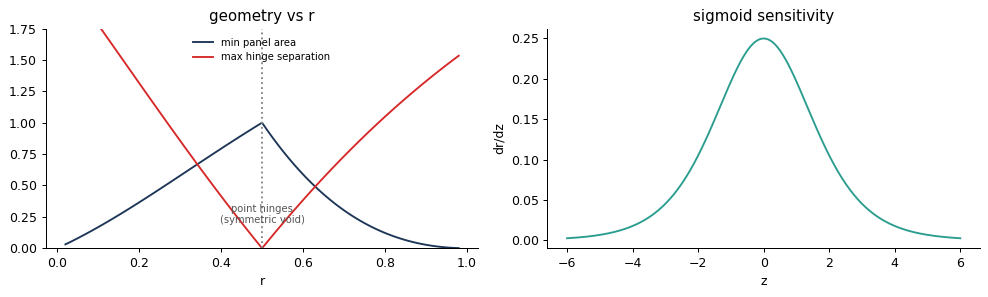

In [7]:
rr = np.linspace(0.02, 0.98, 121)
area = np.array([min_panel_area(geometry(r)[2]) for r in rr])
sep = np.array([np.linalg.norm(np.diff(geometry(r)[1].reshape(-1, 2, 2), axis=1), axis=-1).max() for r in rr])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(rr, area, c="#1d3557", label="min panel area")
ax[0].plot(rr, sep, c="#D62828", label="max hinge separation")
ax[0].axvline(0.5, ls=":", c="#888")
ax[0].annotate("point hinges\n(symmetric void)", (0.5, 0.20), ha="center", fontsize=8, color="#555")
ax[0].set(xlabel="r", title="geometry vs r", ylim=(0, 1.75))
ax[0].legend(frameon=False, fontsize=8, loc="upper center")

z = np.linspace(-6, 6, 400)
s = 1 / (1 + np.exp(-z))
ax[1].plot(z, s * (1 - s), c="#2A9D8F")
ax[1].set(xlabel="z", ylabel="dr/dz", title="sigmoid sensitivity")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

for r in (0.5, 0.9, 0.98):
    i = np.argmin(abs(rr - r))
    print(f"r={r:<5} min panel area {area[i]:.4f}   dr/dz {r*(1-r):.4f}")

So the honest reading of the parameterization:

- **`r = 0.5` is not degenerate** — it is the symmetric, point-hinge design (rotating squares), and
  it is a perfectly reasonable centre for the parameterization to sit on. The `regularization: 1e-4`
  that L2-penalises `z` therefore shrinks toward *that*, which is a sensible symmetric prior, not
  a pull toward a broken configuration.
- **The `(0,1)` range is wider than the usable one.** Panel area falls off a cliff at both ends
  (`0.007` of nominal at `r = 0.95`) while `dr/dz = r(1-r)` gives the *weakest* gradient exactly
  there. If a design wants to live near an extreme, it is slow to get there and un-cuttable when
  it arrives.

Only the second point is a real argument for narrowing the range, and it is about
manufacturability, not validity.